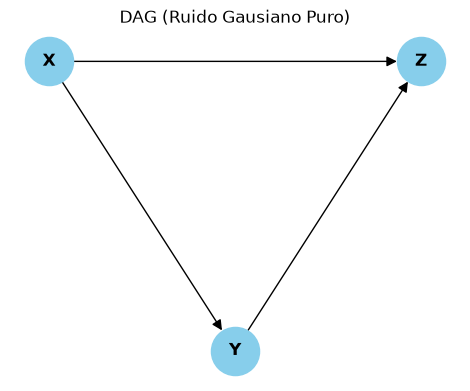


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 100
 -> Entrenando MSE para N=100 y semilla=42...
Using device: cpu
Early stopping at step 50
Using device: cpu
Early stopping at step 75
 -> Entrenando HSIC para N=100 y semilla=42...
Using device: cpu
Early stopping at step 712
Using device: cpu
Early stopping at step 70
 -> Entrenando HYBRID_ALPHA0.1 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 407
Using device: cpu
Early stopping at step 91
 -> Entrenando HYBRID_ALPHA0.2 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 76
Using device: cpu
Early stopping at step 91
 -> Entrenando HYBRID_ALPHA0.3 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 112
Using device: cpu
Early stopping at step 90
 -> Entrenando HYBRID_ALPHA0.4 para N=100 y semilla=42...
Using devic

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,100,1.73964,1.04125,0.10762,4.36684,1.38297,0.27535,0.24904,0.00533,0.12026,0.60000
12,1,42,hsic,HSIC,0.0,1.0,300,2.06787,1.10638,0.04264,17.59745,2.09453,0.08797,0.14414,0.00652,0.10811,0.73333
23,1,42,hsic,HSIC,0.0,1.0,500,2.06862,0.93833,0.06983,39.72889,2.12341,0.08281,0.15228,0.00422,0.06061,0.67000
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,100,1.52936,1.00372,0.16202,2.58984,1.15811,0.24591,0.21012,0.00485,0.07465,0.55000
3,1,42,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,1.48989,0.80487,0.20935,2.53731,1.13369,0.24654,0.20732,0.00825,0.08821,0.65000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10,51,hybrid,HYBRID_ALPHA0.8_BETA0.2,0.8,0.2,500,1.51838,0.82983,0.08824,10.59160,1.08125,0.07382,0.09629,0.00240,0.07004,0.77000
329,10,51,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,1.51726,0.83113,0.08833,10.61430,1.08639,0.07921,0.10246,0.00244,0.07039,0.77000
297,10,51,mse,MSE,1.0,0.0,100,0.91493,0.65902,0.15749,1.41767,0.88509,0.35229,0.28285,0.00322,0.04705,0.60000
308,10,51,mse,MSE,1.0,0.0,300,1.25090,0.83507,0.09331,2.53125,1.04999,0.14942,0.21444,0.00349,0.03359,0.60000


In [1]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gausiano heterocedastico: la desviacion tipica es lineal en los padres."""
    np.random.seed(seed)

    eps_X = np.random.normal(loc=0.0, scale=escala, size=num_samples)
    X = eps_X

    X_std = X / (X.std() + 1e-8)
    sigma_Y = 0.4 + 0.8 * np.abs(X_std)
    sigma_Y = escala * sigma_Y / np.sqrt(np.mean(sigma_Y ** 2))  # iguala la potencia de ruido al caso homocedastico
    eps_Y = sigma_Y * np.random.normal(loc=0.0, scale=1.0, size=num_samples)
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y

    Y_std = (Y - Y.mean()) / (Y.std() + 1e-8)
    sigma_Z = 0.4 + 0.4 * np.abs(X_std) + 0.4 * np.abs(Y_std)  # cada padre aporta de forma monotona e independiente
    sigma_Z = escala * sigma_Z / np.sqrt(np.mean(sigma_Z ** 2))
    eps_Z = sigma_Z * np.random.normal(loc=0.0, scale=1.0, size=num_samples)
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z

    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Gausiano Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "aditivo_gausiano.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

In [4]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # Guardar cada tabla N en un CSV separado
    ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_aditivo_gausiano.csv")
    if not os.path.exists("tablas"):
        os.makedirs("tablas")
    df_resumen_n.to_csv(ruta_resumen_n, index=False)
    print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,2.83439,3.29690,0.93758,0.24703,0.21914,...,0.18983,0.11314,0.21230,0.13709,0.00414,0.00208,0.06270,0.02862,0.605,0.05986
0,0.0,1.0,hsic,HSIC,10,3.97464,5.34385,1.10381,0.24715,0.24770,...,0.27096,0.13596,0.39704,0.13926,0.00534,0.00140,0.10095,0.03503,0.710,0.11005
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,2.57668,2.69132,0.92014,0.22690,0.21351,...,0.17117,0.09334,0.19284,0.13797,0.00415,0.00195,0.05794,0.02950,0.595,0.05503
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,2.53739,2.50109,0.91494,0.21260,0.20946,...,0.17471,0.08798,0.19234,0.13452,0.00422,0.00194,0.05781,0.02891,0.610,0.05676
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,2.54637,2.65567,0.91662,0.23061,0.21335,...,0.16705,0.09065,0.18458,0.13754,0.00410,0.00197,0.06167,0.03007,0.615,0.05297
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,2.62404,2.82219,0.91655,0.23144,0.20578,...,0.17502,0.09067,0.20294,0.15405,0.00412,0.00195,0.05768,0.02996,0.595,0.06852
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,2.65348,2.80874,0.92226,0.22842,0.20648,...,0.17455,0.09779,0.18977,0.14285,0.00415,0.00192,0.05838,0.02924,0.625,0.07546
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,2.67709,3.02846,0.91962,0.23547,0.20787,...,0.17795,0.09734,0.19320,0.13613,0.00408,0.00185,0.06365,0.02818,0.590,0.06146
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,2.66074,3.08375,0.91774,0.24030,0.21308,...,0.17777,0.09344,0.19171,0.13129,0.00429,0.00165,0.06752,0.02701,0.595,0.07619
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,2.75767,3.13355,0.93049,0.22725,0.23068,...,0.17562,0.09567,0.18273,0.13410,0.00405,0.00180,0.06730,0.02601,0.615,0.07091



✓ Tabla resumen guardada en: tablas\resumen_n_100_aditivo_gausiano.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,1.14068,0.24399,0.74690,0.07124,0.08739,...,0.09104,0.03565,0.11167,0.04490,0.00245,0.00049,0.02332,0.01111,0.56000,0.04458
0,0.0,1.0,hsic,HSIC,10,1.71018,0.34868,0.96708,0.10392,0.08345,...,0.17899,0.07328,0.24459,0.12842,0.00428,0.00135,0.11673,0.08966,0.74000,0.09597
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,1.13659,0.23884,0.74586,0.07192,0.08583,...,0.08755,0.03612,0.10562,0.04186,0.00241,0.00056,0.02319,0.01279,0.55167,0.05179
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.10801,0.22754,0.74174,0.06877,0.08526,...,0.08892,0.03490,0.10738,0.04242,0.00235,0.00057,0.02330,0.01320,0.54333,0.05340
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.11618,0.21209,0.74412,0.06767,0.08447,...,0.09405,0.03244,0.11081,0.04486,0.00238,0.00056,0.02392,0.01235,0.55500,0.05829
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.13765,0.15474,0.75071,0.05454,0.08472,...,0.09796,0.02798,0.10751,0.04504,0.00239,0.00050,0.02566,0.01383,0.56167,0.05934
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,1.11203,0.20331,0.74784,0.06514,0.08305,...,0.10326,0.02526,0.10678,0.04452,0.00242,0.00047,0.02611,0.01441,0.54500,0.04651
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,1.12348,0.19788,0.75151,0.06732,0.08377,...,0.10312,0.02554,0.10870,0.04389,0.00250,0.00042,0.02687,0.01602,0.56834,0.04406
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,1.13713,0.21609,0.75790,0.07588,0.07971,...,0.09724,0.03131,0.10988,0.04409,0.00266,0.00048,0.02835,0.01933,0.56000,0.05567
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.16414,0.22325,0.76909,0.08451,0.07611,...,0.09425,0.03076,0.11358,0.04776,0.00281,0.00073,0.03042,0.02155,0.57167,0.05776



✓ Tabla resumen guardada en: tablas\resumen_n_300_aditivo_gausiano.csv



####################################################################################################
# EXPERIMENTO: N = 500 MUESTRAS
####################################################################################################

Tabla resumen para N=500:



...

,Media ± Std
MSE Y,1.38906 ± 0.43103
MAE Y,0.79621 ± 0.07906
"HSIC(Y,X)",0.10331 ± 0.06738
MSE Z,3.04460 ± 3.03716
MAE Z,0.89958 ± 0.10260
"HSIC(Z,X)",0.09033 ± 0.02548
"HSIC(Z,Y)",0.09669 ± 0.02797
dHSIC Total,0.00202 ± 0.00054
MMD,0.02329 ± 0.01881
RF Acc,0.66200 ± 0.06391



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.41862 ± 0.47869
MAE Y,0.80229 ± 0.08782
"HSIC(Y,X)",0.10528 ± 0.07273
MSE Z,2.90763 ± 3.05673
MAE Z,0.88467 ± 0.10232
"HSIC(Z,X)",0.09204 ± 0.02754
"HSIC(Z,Y)",0.09188 ± 0.02790
dHSIC Total,0.00191 ± 0.00061
MMD,0.02311 ± 0.01909
RF Acc,0.65200 ± 0.06529



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.41825 ± 0.49097
MAE Y,0.80373 ± 0.09082
"HSIC(Y,X)",0.10477 ± 0.07377
MSE Z,2.99577 ± 3.03566
MAE Z,0.89354 ± 0.10696
"HSIC(Z,X)",0.09925 ± 0.03158
"HSIC(Z,Y)",0.09773 ± 0.03165
dHSIC Total,0.00199 ± 0.00063
MMD,0.02291 ± 0.01922
RF Acc,0.64700 ± 0.05677



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)

✓ Gráfica consolidada guardada: plots\bandplot_todas_N_aditivo_gausiano.png



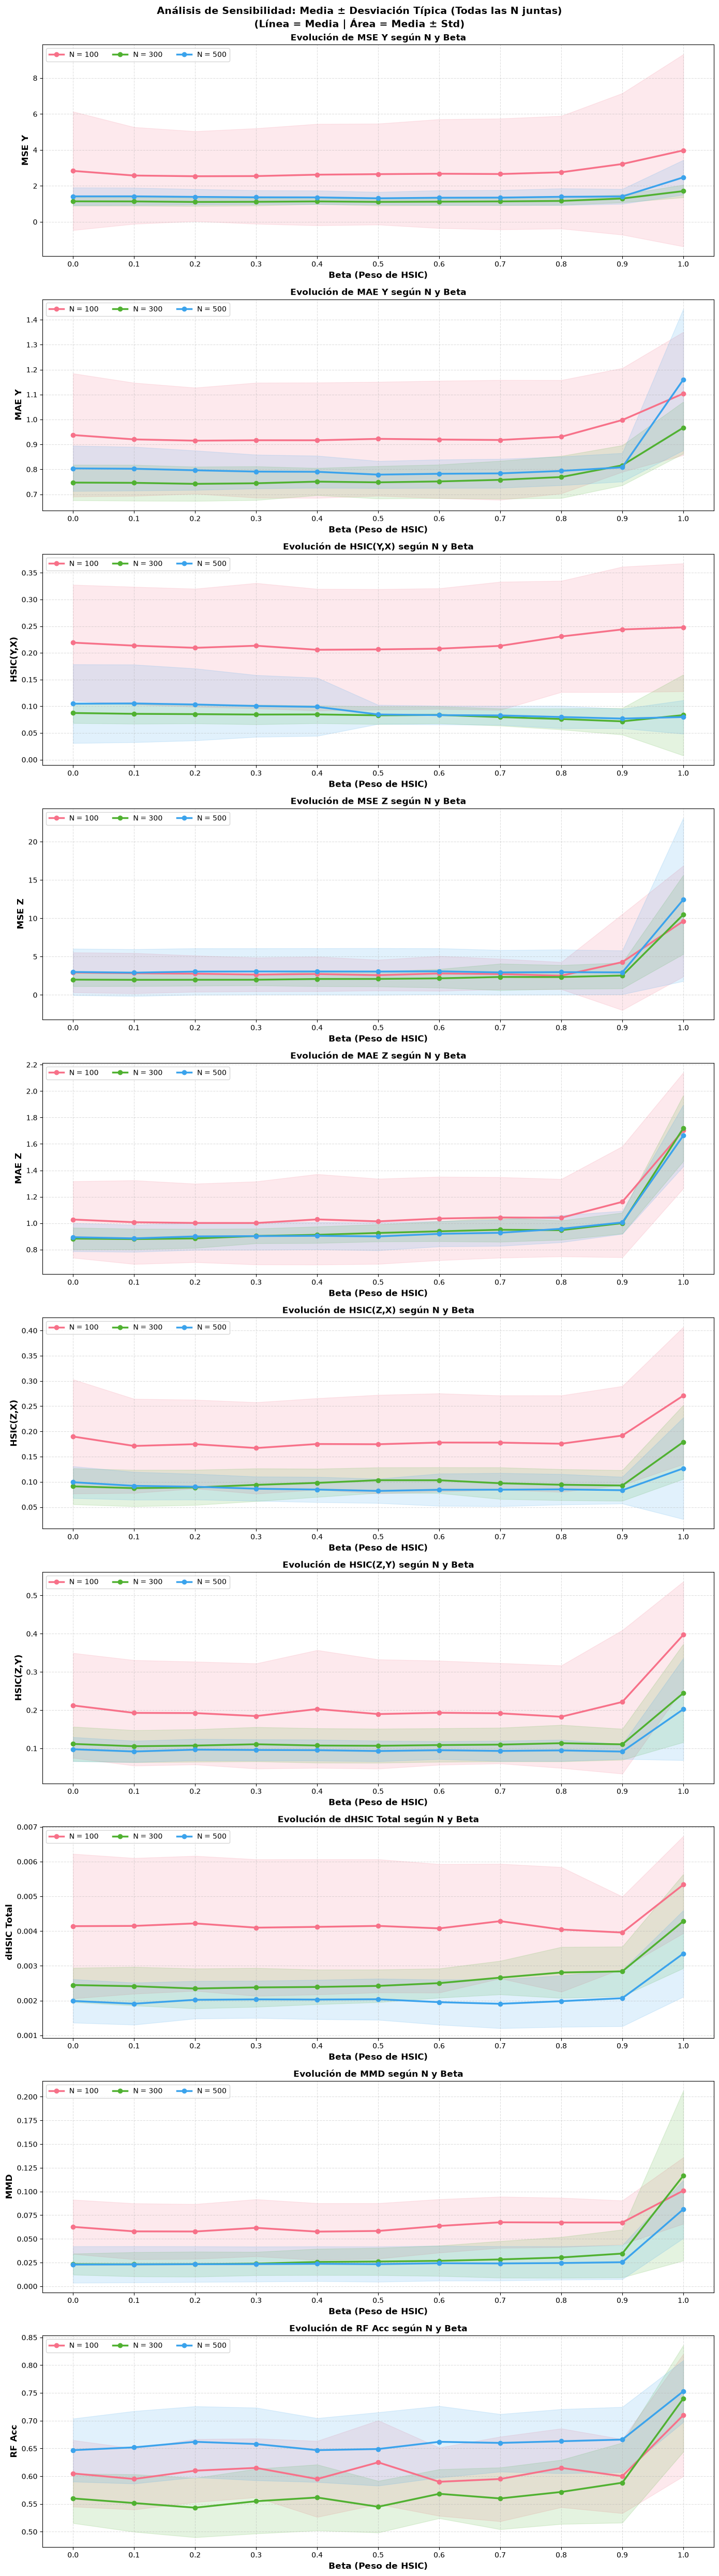

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [5]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std)', 
             fontsize=14, fontweight='bold', y=0.995)

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    
    # Para cada N, graficar una línea
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        
        # Extraer valores de media y std
        x = df_n_data['Beta'].values
        y_mean = df_n_data[f'{metrica}_mean'].values
        y_std = df_n_data[f'{metrica}_std'].values
        
        # Calcular límites superiores e inferiores
        y_upper = y_mean + y_std
        y_lower = y_mean - y_std
        
        # Graficar: línea para media y área para std
        color = paleta_n[n_val]
        ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}', 
               color=color, markersize=6)
        ax.fill_between(x, y_lower, y_upper, alpha=0.15, color=color)
    
    # Estética
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.set_xlim(-0.05, 1.05)
    
    # Establecer ticks en X
    ax.set_xticks(sorted(df_global['Beta'].unique()))

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_aditivo_gausiano.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")